In [36]:
from matplotlib import pyplot as plt
import pandas as pd
import polars as pl
import joblib
import gc

In [ ]:
news_real_labels = ['reliable']
news_fake_labels = ['bias','fake','unreliable','rumor','conspiracy','clickbait','junksci','satire','political','hate']

df_news = (
    pl.scan_csv('data/995,000_rows.csv')
    .select([
        pl.col('type').alias('isfake'),
        pl.col('content')
    ])
    .filter(pl.col('isfake').is_in(news_real_labels + news_fake_labels))
    .with_columns(
        pl.when(pl.col('isfake').is_in(news_fake_labels))
        .then(1)
        .otherwise(0)
        .alias('isfake')
    )
    .collect()
)

In [30]:
liar_real_labels = ['mostly-true', 'true']
liar_fake_labels = ['false','pants-fire', 'half-true', 'barely-true']

df_liar = (
    pl.scan_csv('liar_dataset/aggregated.csv')
    .select([
        pl.col('isfake'),
        pl.col('title').alias('content')
    ])
    .filter(pl.col('isfake').is_in(liar_real_labels + liar_fake_labels))
    .with_columns(
        pl.when(pl.col('isfake').is_in(liar_fake_labels))
        .then(1)
        .otherwise(0)
        .alias('isfake')
    )
    .collect()
)

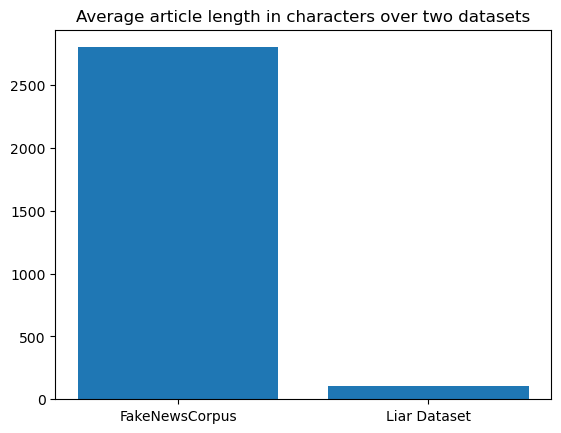

In [ ]:
# Barplot over article counts
def get_avg_len(series): return (series.str.len_chars().mean())

x_lab = ['FakeNewsCorpus', 'Liar Dataset']
# Average length of articles
news_avg = get_avg_len(df_news['content'])
liar_avg = get_avg_len(df_liar['content'])

plt.bar(x_lab, [news_avg, liar_avg])
plt.title('Average article length in characters over two datasets')
plt.savefig('data/dataset_len_avg.png')
plt.show()

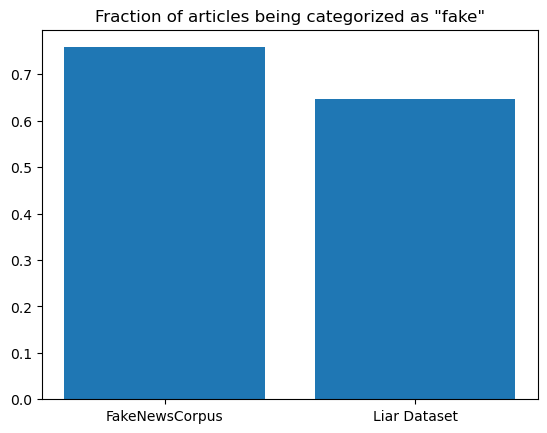

In [33]:
# Fraction of articles being classified as fake
news_frac = sum(df_news['isfake']) / len(df_news)
liar_frac = sum(df_liar['isfake']) / len(df_liar)

plt.bar(x_lab, [news_frac, liar_frac])
plt.title('Fraction of articles being categorized as "fake"')
plt.show()

In [27]:
[news_frac, liar_frac]

[0.7581399916729258, 0.6476384110103222]

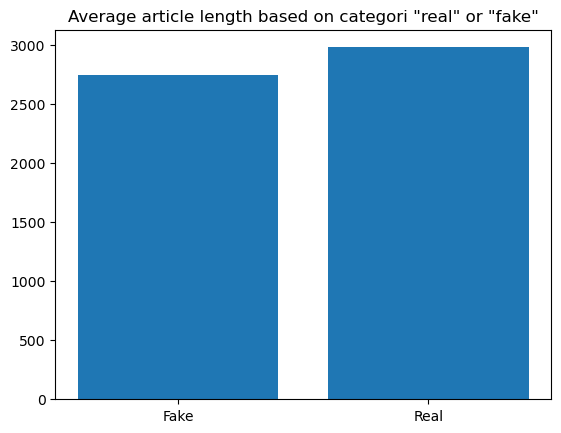

In [34]:
# Testing difference in length based on real or fake categori.

df_fake = df_news.filter(pl.col('isfake') == 1)
df_real = df_news.filter(pl.col('isfake') == 0)

fake_avg = get_avg_len(df_fake['content'])
real_avg = get_avg_len(df_real['content'])

x_lab = ['Fake', 'Real']

plt.bar(x_lab, [fake_avg, real_avg])
plt.title('Average article length based on categori "real" or "fake"')
plt.savefig('data/label_len_avg.png')
plt.show()

In [ ]:
del df_fake, df_real
gc.collect()

16595

In [40]:
df_liar = df_liar.with_columns(pl.col('content').map_elements(lambda x : len(x)).alias('length'))
df_news = df_news.with_columns(pl.col('content').map_elements(lambda x : len(x)).alias('length'))

In [51]:
# Median and quartile lengths for the Liar dataset article lengths
q1 = df_liar.select(pl.col('length')).quantile(0.25).to_numpy()[0][0]
med = df_liar.select(pl.col('length')).quantile(0.5).to_numpy()[0][0]
q3 = df_liar.select(pl.col('length')).quantile(0.75).to_numpy()[0][0]
print(f'1st quantile: {q1}, median: {med}, 3rd quantile: {q3}')

1st quantile: 73.0, median: 99.0, 3rd quantile: 133.0


In [53]:
# Now calculate the probability of an article in FakeNewsCorpus train set 
# being fake if restricted to each of the quartiles as max length.
df_q1 = df_news.filter(pl.col('length') <= q1)
df_med = df_news.filter(pl.col('length') <= med)
df_q3 = df_news.filter(pl.col('length') <= q3)

prob_q1 = len(df_q1.filter(pl.col('isfake') == 1)) / len(df_q1)
prob_med = len(df_med.filter(pl.col('isfake') == 1)) / len(df_med)
prob_q3 = len(df_q3.filter(pl.col('isfake') == 1)) / len(df_q3)

print(
    'Probability of an article in FakeNewsCorpus being fake given that its\n'\
    'length is smaller than the specified length quantiles from the Liar dataset:\n'\
    f'1st quantile: {prob_q1:.3f}\t'\
    f'Median: {prob_med:.3f}\t'\
    f'3rd quantile: {prob_q3:.3f}'
)

Probability of an article in FakeNewsCorpus being fake given that its
length is smaller than the specified length quantiles from the Liar dataset:
1st quantile: 0.799	Median: 0.879	3rd quantile: 0.931


In [23]:
# Last year updated
max_year = (
    df_news.select(
        pl.col("updated_at")
        .str.to_datetime()
        .dt.year()              
        .max()                  
    )
    .item()
)
max_year

2018